In [3]:
import pandas as pd
import matplotlib.pyplot as plt

In [21]:

# Step 1: Load the datasets
# Replace these paths with the actual paths to your files
file1_path = 'API_SP.POP.TOTL_DS2_en_csv_v2_900.csv'  # Population data
file2_path = 'Metadata_Country_API_SP.POP.TOTL_DS2_en_csv_v2_900.csv'  # Country metadata

# Read the datasets
try:
    data_file1 = pd.read_csv(file1_path, skiprows=4)  # Skip header rows
    data_file2 = pd.read_csv(file2_path)
except FileNotFoundError:
    print("Error: Please make sure the file paths are correct.")
    exit()

In [22]:
# Step 2: Merge population data with country metadata on 'Country Code'
merged_data = pd.merge(data_file1, data_file2, on="Country Code", how="left")

In [24]:
# Step 3: Filter relevant columns for the year 2023
if "2023" not in merged_data.columns:
    print("Error: The dataset does not contain data for the year 2023.")
    exit()

population_2023 = merged_data[["Country Name", "Region", "IncomeGroup", "2023"]].dropna()


In [25]:
# Rename the columns for better clarity
population_2023.rename(columns={"2023": "Population"}, inplace=True)

In [26]:
# Step 4: Group population by region and calculate the total population for each region
region_population = population_2023.groupby("Region")["Population"].sum().sort_values(ascending=False)


In [27]:
# Check if there is data to plot
if region_population.empty:
    print("Error: No data available to plot.")
    exit()


<Axes: xlabel='Region'>

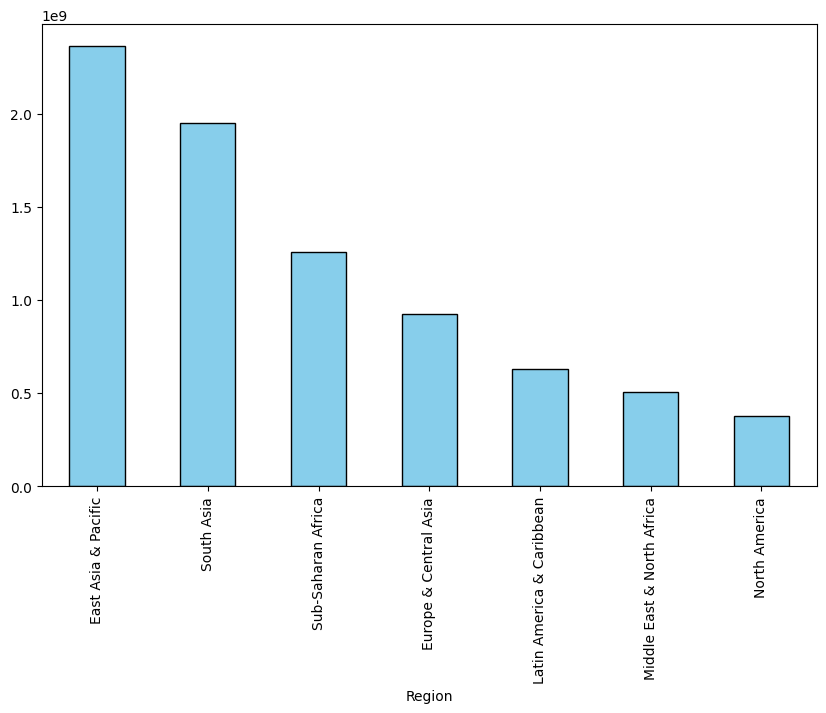

In [28]:
# Step 5: Plot the bar chart
plt.figure(figsize=(10, 6))
region_population.plot(kind="bar", color="skyblue", edgecolor="black")


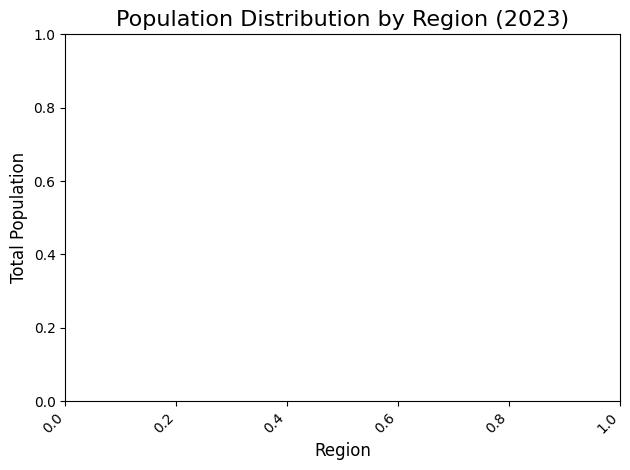

In [32]:
# Add chart details
plt.title("Population Distribution by Region (2023)", fontsize=16)
plt.xlabel("Region", fontsize=12)
plt.ylabel("Total Population", fontsize=12)
plt.xticks(rotation=45, ha="right")
plt.tight_layout()



In [33]:
# Show the plot
plt.show()